In [1]:
import numpy as np
import tiktoken
import torch
from torch import nn
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
import matplotlib.pyplot as plt

In [2]:
data = open('/home/ak/Downloads/paul_graham_essay.txt').read()

# Char encoding

In [3]:
vocab = sorted(set(data))
vocab_size = len(vocab)
stoi = {c:i for i, c in enumerate(vocab)}
itos = {i:c for i, c in enumerate(vocab)}
encode = lambda x: [stoi[c] for c in x]
decode = lambda x: [itos[i] for i in x]

# BPE encoding

In [15]:
tiktoken.list_encoding_names()

['gpt2', 'r50k_base', 'p50k_base', 'p50k_edit', 'cl100k_base']

In [16]:
enc = tiktoken.get_encoding('gpt2')

In [17]:
enc.name

'gpt2'

In [18]:
enc.n_vocab

50257

In [19]:
vocab_size = enc.n_vocab
encode = enc.encode
decode = enc.decode

# Params

In [4]:
device = 'cpu'

In [5]:
data = torch.tensor(encode(data)).to(device)

In [6]:
data

tensor([52, 69, 80,  ..., 25, 15,  0])

In [7]:
# Char encoding
context_len = 32
n_embd = 32
head_size = n_embd // 4
n_heads = 4
n_blocks = 2
bias = False
lr = 3e-4
batch_size = 32
eval_iters = 200
train_iters = 70_000
report_interval = 1000

## BPE encoding
# context_len = 256
# vocab_size = enc.n_vocab
# n_embd = 768
# head_size = n_embd // 4
# n_heads = 4
# n_blocks = 2
# bias = False
# lr = 3e-4
# batch_size = 32
# eval_iters = 200
# train_iters = 70_000
# report_interval = 1000

In [8]:
train_data = data[:int(0.9 * len(data))]
test_data = data[int(0.9 * len(data)):]

# Transformer

In [9]:
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.query = nn.Linear(n_embd, n_heads * head_size, bias=bias)
        self.key = nn.Linear(n_embd, n_heads * head_size, bias=bias)
        self.value = nn.Linear(n_embd, n_heads * head_size, bias=bias)
        self.proj = nn.Linear(n_heads * head_size, n_embd)
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            print('Using slow manual attention')
            self.register_buffer('mask', torch.tril(torch.ones(context_len, context_len)) == 0)
        
    def forward(self, x):
        B, T, C = x.shape
        
        q = self.query(x).view(B, T, n_heads, head_size).transpose(1, 2) # B, n_heads, T, head_size
        k = self.key(x).view(B, T, n_heads, head_size).transpose(1, 2) # B, n_heads, T, head_size
        v = self.value(x).view(B, T, n_heads, head_size).transpose(1, 2) # B, n_heads, T, head_size
        
        if self.flash:
            out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        else:
            weights = (q @ k.transpose(-2, -1)) / np.sqrt(head_size) # B, n_heads, T, T
            weights = weights.masked_fill(self.mask[:T, :T], float('-inf'))
            weights = F.softmax(weights, dim=-1)
            out = weights @ v # B, n_heads, T, head_size
        
        out = out.transpose(1, 2).contiguous().view(B, T, n_heads * head_size) # B, T, n_heads * head_size
        out = self.proj(out) # B, T, n_embd
        return out
    
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
        )
    
    def forward(self, x):
        out = self.layers(x)
        return out

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.att = CausalSelfAttention()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ffwd = FeedForward()
        self.ln2 = nn.LayerNorm(n_embd)
    
    def forward(self, x):
        x = x + self.att(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(context_len, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_blocks)])
        self.ln = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
    
    def forward(self, x):
        B, T = x.shape
        
        x = self.token_emb(x) # B, T, n_embd
        pos = self.pos_emb(torch.arange(T).to(device)) # T, n_embd
        
        # positional encoding
        x = x + pos # B, T, n_embd
        
        out = self.blocks(x) # B, T, n_embd
        out = self.ln(out)
        out = self.lm_head(out) # B, T, vocab_size
        
        return out

In [10]:
def get_batch(data):
    idx = torch.randint(0, len(data) - context_len, (batch_size,))
    X = torch.stack([data[i: i+context_len] for i in idx])
    y = torch.stack([data[i+1: i+context_len+1] for i in idx])
    return X, y

@torch.no_grad()
def evaluate_loss():
    losses = {}
    for name, data in [('train', train_data), ('test', test_data)]:
        loss = 0
        for itr in range(eval_iters):
            X, y = get_batch(data)
            pred = gpt(X)
            pred = pred.flatten(0, 1)
            y = y.flatten()
            loss += loss_fn(pred, y).item()
        losses[name] = loss / eval_iters
    return losses

In [11]:
train_loss, val_loss = [], []
def train():
    for itr in range(train_iters):
        X, y = get_batch(train_data)
        # forward pass
        pred = gpt(X)
        # calc loss
        pred = pred.flatten(0, 1)
        y = y.flatten()
        loss = loss_fn(pred, y)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # report
        if (itr+1) % report_interval == 0:
            losses = evaluate_loss()
            train_loss.append(losses['train'])
            val_loss.append(losses['test'])
            print(f'Step: {itr+1:<6} | Training Loss: {losses["train"]:.7f} | Validation Loss: {losses["test"]:.7f}')

In [12]:
gpt = GPT().to(device)

In [13]:
gpt.load_state_dict(torch.load('babygpt.pt', map_location=device))

<All keys matched successfully>

In [14]:
optimizer = torch.optim.Adam(gpt.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [48]:
%%time
train()

Step: 1000   | Training Loss: 2.6327072 | Validation Loss: 2.6726031
Step: 2000   | Training Loss: 2.4296306 | Validation Loss: 2.4899143
Step: 3000   | Training Loss: 2.2995640 | Validation Loss: 2.3984104
Step: 4000   | Training Loss: 2.2095193 | Validation Loss: 2.3037178
Step: 5000   | Training Loss: 2.1363869 | Validation Loss: 2.2437682
Step: 6000   | Training Loss: 2.0683913 | Validation Loss: 2.1850450
Step: 7000   | Training Loss: 2.0128910 | Validation Loss: 2.1376235
Step: 8000   | Training Loss: 1.9738931 | Validation Loss: 2.1003598
Step: 9000   | Training Loss: 1.9540893 | Validation Loss: 2.0642198
Step: 10000  | Training Loss: 1.9135562 | Validation Loss: 2.0302295
Step: 11000  | Training Loss: 1.8867138 | Validation Loss: 2.0203217
Step: 12000  | Training Loss: 1.8770363 | Validation Loss: 1.9996528
Step: 13000  | Training Loss: 1.8465776 | Validation Loss: 1.9761006
Step: 14000  | Training Loss: 1.8415548 | Validation Loss: 1.9781100
Step: 15000  | Training Loss: 1.81

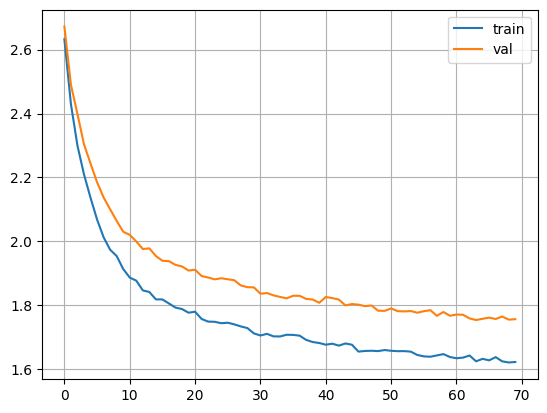

In [50]:
plt.plot(train_loss, label='train')
plt.plot(val_loss, label='val')
plt.grid(True)
plt.legend()

In [52]:
torch.save(gpt.state_dict(), 'babygpt.pt')

In [16]:
# generation

temp = 0.3
x = 'i love'
print(x, end='')
x = torch.tensor(encode(x)).to(device)
h = None

for i in range(500):
    # forward pass
    pred = gpt(x[None, -context_len:])

    # construct categorical distribution and sample a character
    dist = Categorical(logits=(pred[-1, -1]/temp))
    idx = dist.sample()

    # print the sampled character
    print(itos[idx.item()], end='')

    # next input is current output
    x = torch.cat((x, idx[None]))

i love what the some more the problems in the way can the startups will the have startups the a startup is in the are to companies a startups at to startups are a makes a startups the prograps the probably is the most an the a company companies what it a companies a companies the most of the startups are the read to do the well to be something that the most the company to make is that the doing to startups to be a busing that a companies of the the doing a startups that was it the a companies a compan

Transformer have a few limitations:
* Since the positional encodings are learned while training as part of embedding table, we can an input with tokens more than the max context length :(
* For inputs with large context length the attention weight matrix will be huge and take up a lot of space :(

# RNN (LSTM)

In [121]:
class CharRNN(nn.Module):
    def __init__(self, hidden_size, n_layers):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, n_embd)
        self.rnn = nn.LSTM(n_embd, hidden_size, n_layers)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, 4 * hidden_size),
            nn.Linear(4 * hidden_size, hidden_size),
            nn.Linear(hidden_size, vocab_size),
        )
        
    def forward(self, x, h=None):
        x = self.emb(x)
        x = x.transpose(0, 1) # brings ith element of all batches together
        out, h = self.rnn(x, h)
        out = out.transpose(0, 1)
        out = self.decoder(out)
        return out, (h[0].detach(), h[1].detach())

In [122]:
def get_batch(data):
    idx = torch.randint(0, len(data) - context_len, (batch_size,))
    X = torch.stack([data[i: i+context_len] for i in idx])
    y = torch.stack([data[i+1: i+context_len+1] for i in idx])
    return X, y

@torch.no_grad()
def evaluate_loss():
    losses = {}
    for name, data in [('train', train_data), ('test', test_data)]:
        loss = 0
        for itr in range(eval_iters):
            X, y = get_batch(data)
            pred, _ = rnn(X)
            pred = pred.flatten(0, 1)
            y = y.flatten()
            loss += loss_fn(pred, y).item()
        losses[name] = loss / eval_iters
    return losses

In [123]:
train_loss, val_loss = [], []
def train():
    h = None
    for itr in range(train_iters):
        X, y = get_batch(train_data)
        # forward pass
        pred, h = rnn(X, h)
        # calc loss
        pred = pred.flatten(0, 1)
        y = y.flatten()
        loss = loss_fn(pred, y)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # report
        if (itr+1) % report_interval == 0:
            losses = evaluate_loss()
            train_loss.append(losses['train'])
            val_loss.append(losses['test'])
            print(f'Step: {itr+1:<6} | Training Loss: {losses["train"]:.7f} | Validation Loss: {losses["test"]:.7f}')

In [124]:
rnn = CharRNN(2 * n_embd, 4).to(device)

In [125]:
optimizer = torch.optim.Adam(rnn.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [126]:
%%time
train()

Step: 1000   | Training Loss: 2.1967572 | Validation Loss: 2.2920810
Step: 2000   | Training Loss: 1.9507227 | Validation Loss: 2.0705690
Step: 3000   | Training Loss: 1.8262493 | Validation Loss: 1.9420611
Step: 4000   | Training Loss: 1.7298564 | Validation Loss: 1.8544104
Step: 5000   | Training Loss: 1.6737605 | Validation Loss: 1.7949853
Step: 6000   | Training Loss: 1.6294951 | Validation Loss: 1.7609841
Step: 7000   | Training Loss: 1.5987263 | Validation Loss: 1.7292850
Step: 8000   | Training Loss: 1.5875039 | Validation Loss: 1.7078310
Step: 9000   | Training Loss: 1.5670647 | Validation Loss: 1.6813152
Step: 10000  | Training Loss: 1.5374429 | Validation Loss: 1.6635361
Step: 11000  | Training Loss: 1.5267242 | Validation Loss: 1.6507362
Step: 12000  | Training Loss: 1.5194207 | Validation Loss: 1.6279995
Step: 13000  | Training Loss: 1.4993374 | Validation Loss: 1.6373492
Step: 14000  | Training Loss: 1.4921559 | Validation Loss: 1.6194430
Step: 15000  | Training Loss: 1.48

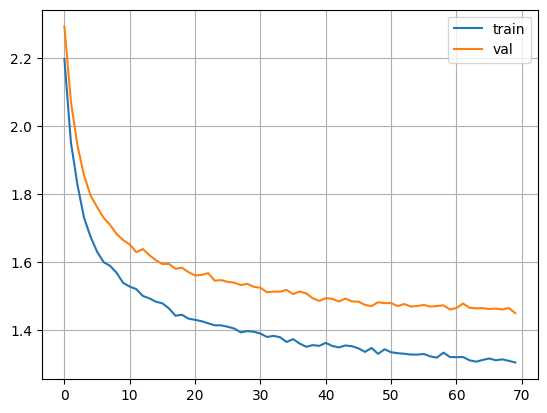

In [127]:
plt.plot(train_loss, label='train')
plt.plot(val_loss, label='val')
plt.grid(True)
plt.legend()

In [128]:
torch.save(rnn.state_dict(), 'babyrnn.pt')

In [194]:
# generation
temp = 0.3
x = 'a startup is'
print(x, end='')
x = torch.tensor(encode(x)).to(device)
h = None

for i in range(500):
    # forward pass
    out, h = rnn(x.unsqueeze(0), h)

    # construct categorical distribution and sample a character
    dist = Categorical(logits=(out/temp))
    idx = dist.sample().squeeze(0)[-1]

    # print the sampled character
    print(itos[idx.item()], end='')

    # next input is current output
    x = torch.cat((x, idx[None]))

a startup is the problem with a few deals would be a lot of magnet to the company when you can do it as a startup was a big companies were a large and the same work of a startup is that they were so much as a problem is a big company and startups are not a lot of people who want to be able to a company that would be a board and the average of the founders are not a lot of money and the other reason when you want to be a bad idea of the way to focus on the same thing to start a startup is the most important 

In [242]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [243]:
x = torch.randn(3200, 10)

In [244]:
layer1 = nn.Linear(10, 10, bias=False)
layer2 = nn.Linear(10, 10, bias=False)
layer3 = nn.Linear(10, 10, bias=False)
layer4 = nn.Linear(10, 10, bias=False)
layer5 = nn.Linear(10, 10, bias=False)
layer6 = nn.Linear(10, 10, bias=False)

In [245]:
with torch.no_grad():
    outs = []
    outs.append(layer1(x))
    outs.append(layer2(outs[-1]))
    outs.append(layer3(outs[-1]))
    outs.append(layer4(outs[-1]))
    outs.append(layer5(outs[-1]))
    outs.append(layer6(outs[-1]))

tensor(-0.0018) tensor(0.5840)
tensor(0.0019) tensor(0.3402)
tensor(-0.0003) tensor(0.2006)
tensor(0.0004) tensor(0.1054)
tensor(-0.0006) tensor(0.0704)
tensor(-0.0004) tensor(0.0425)


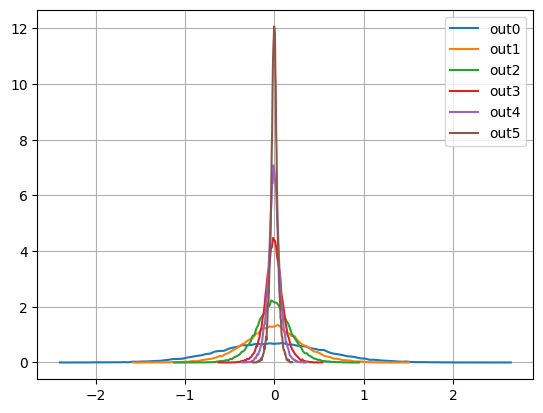

In [246]:
for i, out in enumerate(outs):
    y, x = out.histogram(bins=100, density=True)    
    print(out.flatten().mean(), out.flatten().std())
    plt.plot(x[:-1], y, label=f'out{i}')
plt.grid()
plt.legend()

In [237]:
x = torch.randn(32000, 10)

In [238]:
W = torch.randn(10, 10) / 10 ** 0.5

In [239]:
out1 = x @ W.T 
W = torch.randn(100, 10) / (10 ** 0.5)
out2 = out1 @ W.T 
W = torch.randn(50, 100) / (100 ** 0.5)
out3 = out2 @ W.T 
W = torch.randn(10, 50) / (50 ** 0.5)
out4 = out3 @ W.T 
W = torch.randn(5, 10) / (10 ** 0.5)
out5 = out4 @ W.T 
W = torch.randn(10, 5) / (5 ** 0.5)
out6 = out5 @ W.T 

In [240]:
outs = [out1, out2, out3, out4, out5, out6]

tensor(0.0059) tensor(1.0113)
tensor(0.0012) tensor(1.0429)
tensor(0.0014) tensor(0.9992)
tensor(0.0013) tensor(0.8850)
tensor(-0.0036) tensor(0.7481)
tensor(-0.0033) tensor(0.7061)


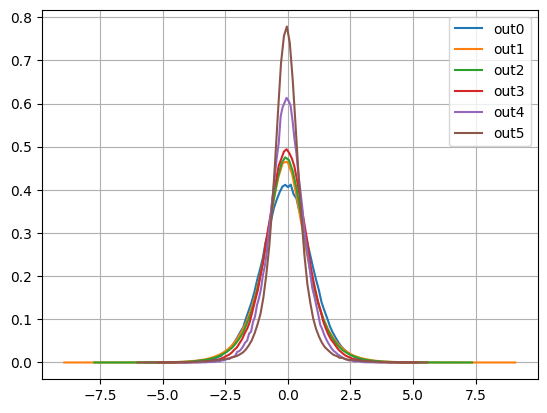

In [241]:
for i, out in enumerate(outs):
    y, x = out.histogram(bins=100, density=True)    
    print(out.flatten().mean(), out.flatten().std())
    plt.plot(x[:-1], y, label=f'out{i}')
plt.grid()
plt.legend()